# Data Analytics Case Study 3: Project
Bruno Sassi - NF1008627

Maria Aguilar - NF1009877

Luciana Popa - NF1005554

Tiago Ceolato – NF1006634

#Libraries

In [54]:
# Importing libraries for the GOOGL stock price prediction, using
# Multiple linear regression and Gradient boosting.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone


In [55]:
# Loading and preparing the dataset:

df = pd.read_csv("C:/Users/mcaro/googl_prices_trends_merged.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

#EDA

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   index                 1256 non-null   int64         
 1   Date                  1256 non-null   datetime64[ns]
 2   Open                  1256 non-null   float64       
 3   High                  1256 non-null   float64       
 4   Low                   1256 non-null   float64       
 5   Close                 1256 non-null   float64       
 6   Adj_Close             1256 non-null   float64       
 7   Volume                1256 non-null   int64         
 8   trend_alphabet        1256 non-null   int64         
 9   trend_alphabet_lag1   1255 non-null   float64       
 10  trend_alphabet_lag7   1249 non-null   float64       
 11  trend_alphabet_lag28  1228 non-null   float64       
 12  Adj_Close_lag1        1255 non-null   float64       
 13  Adj_Close_lag7    

In [57]:
df.head()

,index,Date,Open,High,Low,Close,Adj_Close,Volume,trend_alphabet,trend_alphabet_lag1,...,MA10,MA20,MA50,MA200,Volatility20,Price_lag1,Price_lag5,RSI,MACD,Signal
0,0,2020-08-26,80.315002,82.639503,80.049004,82.206497,81.716423,52188000,34,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
1,1,2020-08-27,82.330498,82.399498,80.940498,81.426003,80.940567,31350000,34,34.0,...,NaN,NaN,NaN,NaN,NaN,81.716423,NaN,0.000000,-0.061892,-0.012378
2,2,2020-08-28,81.473503,82.067497,81.280502,81.971497,81.482819,22418000,34,34.0,...,NaN,NaN,NaN,NaN,NaN,80.940567,NaN,42.944181,-0.066420,-0.023187
3,3,2020-08-31,82.178497,82.224998,81.266502,81.476501,80.990776,26422000,32,34.0,...,NaN,NaN,NaN,NaN,NaN,81.482819,NaN,30.249763,-0.108463,-0.040242
4,4,2020-09-01,81.608002,82.960999,81.476501,82.753998,82.260651,22652000,32,32.0,...,NaN,NaN,NaN,NaN,NaN,80.990776,NaN,61.708994,-0.038866,-0.039967


In [58]:
df.isnull().sum()

index                     0
Date                      0
Open                      0
High                      0
Low                       0
Close                     0
Adj_Close                 0
Volume                    0
trend_alphabet            0
trend_alphabet_lag1       1
trend_alphabet_lag7       7
trend_alphabet_lag28     28
Adj_Close_lag1            1
Adj_Close_lag7            7
Adj_Close_lag28          28
Close_lag1                1
Close_lag7                7
Close_lag28              28
Return                    1
Change %                  1
MA10                      9
MA20                     19
MA50                     49
MA200                   199
Volatility20             20
Price_lag1                1
Price_lag5                5
RSI                       1
MACD                      0
Signal                    0
dtype: int64

In [59]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
index,1256.0,627.5,0.0,313.75,627.5,941.25,1255.0,362.720278
Date,1256,2023-02-23 14:34:46.624203776,2020-08-26 00:00:00,2021-11-22 18:00:00,2023-02-23 12:00:00,2024-05-23 06:00:00,2025-08-26 00:00:00,NaN
Open,1256.0,132.975832,70.134003,106.594999,133.202751,156.569996,207.789993,31.694682
High,1256.0,134.514085,71.899498,108.019999,134.254997,159.025002,210.520004,31.935719
Low,1256.0,131.523393,70.107498,105.133501,131.32,154.994995,205.774994,31.408555
Close,1256.0,133.038438,70.469498,107.185873,133.284004,157.087505,208.490005,31.685718
Adj_Close,1256.0,132.395715,70.049393,106.546879,132.489418,156.648479,208.490005,31.709166
Volume,1256.0,32198839.811306,9312000.0,23333150.0,28874400.0,36864550.0,127490100.0,13669601.909962
trend_alphabet,1256.0,22.145701,0.0,0.0,26.0,34.0,100.0,19.146288
trend_alphabet_lag1,1255.0,22.151394,0.0,0.0,26.0,34.0,100.0,19.152857


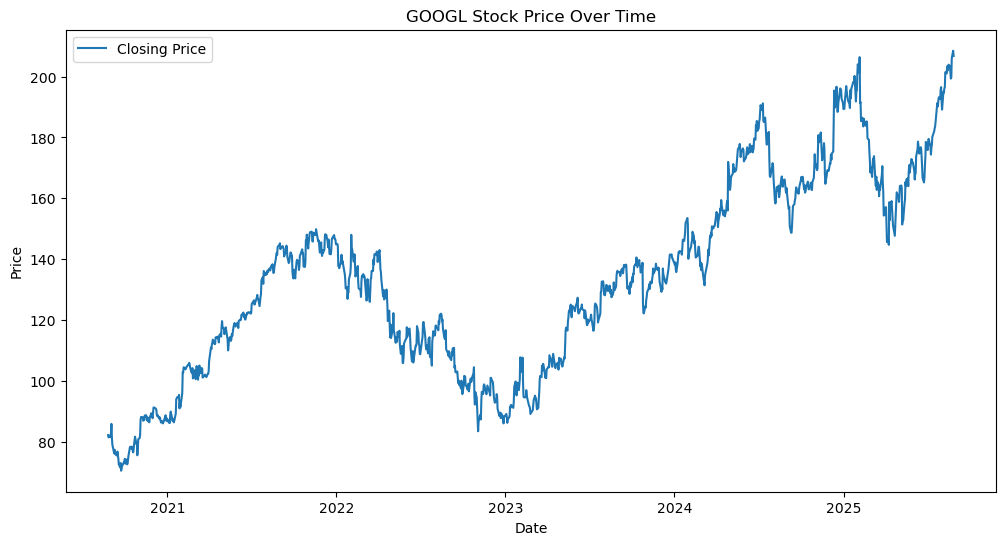

In [60]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Closing Price')
plt.title("GOOGL Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

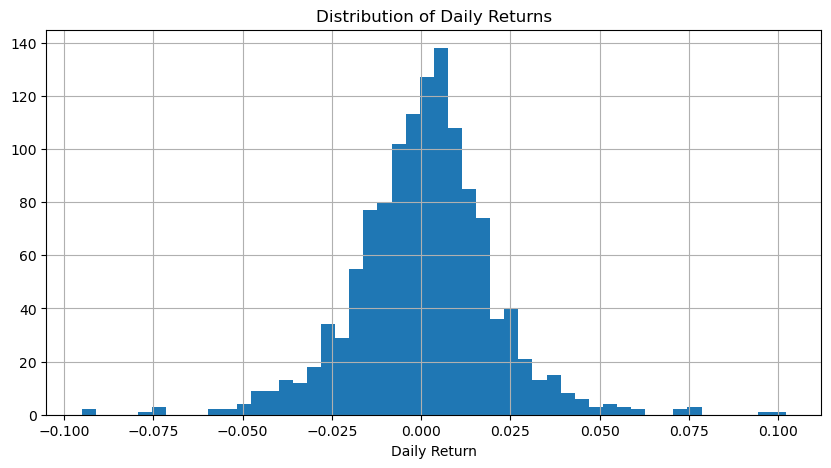

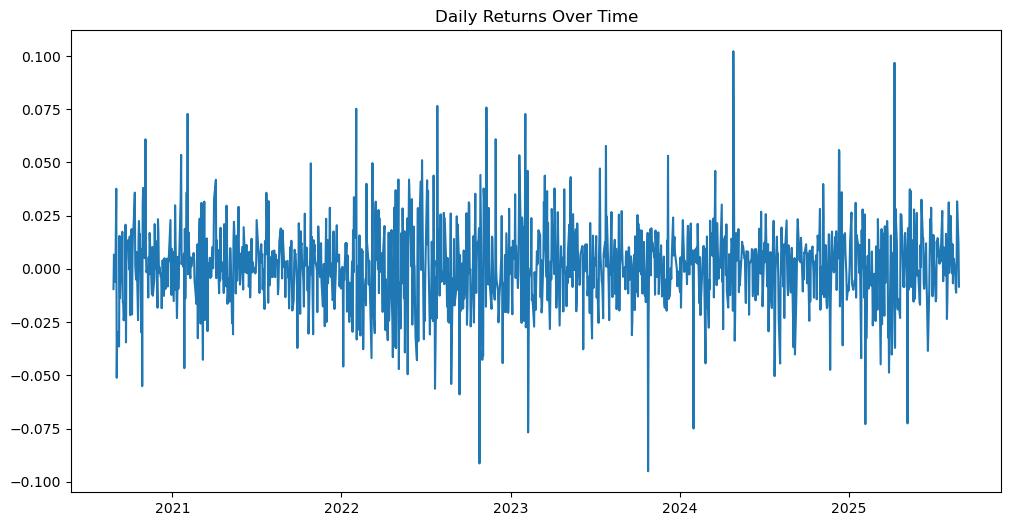

In [61]:
plt.figure(figsize=(10,5))
df['Return'].hist(bins=50)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Return'], label='Daily Return')
plt.title("Daily Returns Over Time")
plt.show()


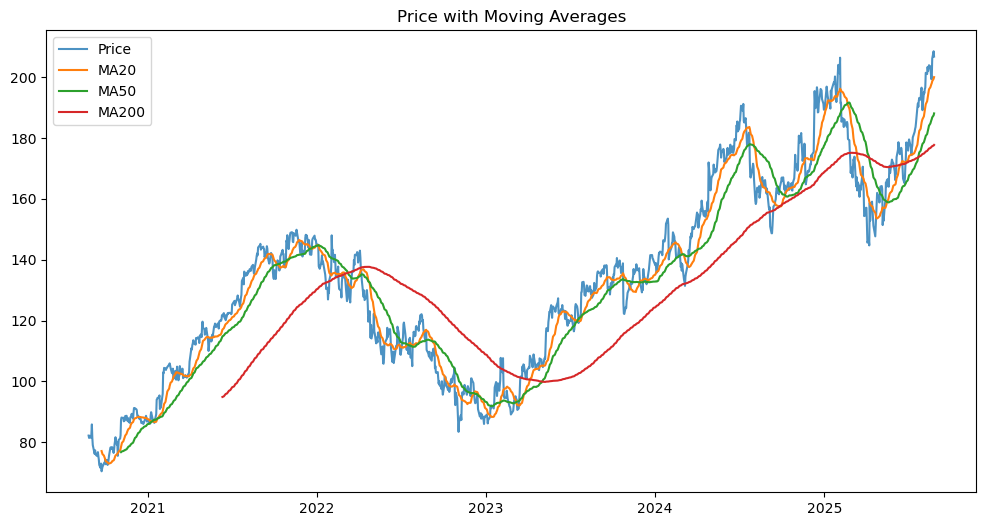

In [62]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Price', alpha=0.8)
plt.plot(df['Date'], df['MA20'], label='MA20')
plt.plot(df['Date'], df['MA50'], label='MA50')
plt.plot(df['Date'], df['MA200'], label='MA200')
plt.title("Price with Moving Averages")
plt.legend()
plt.show()

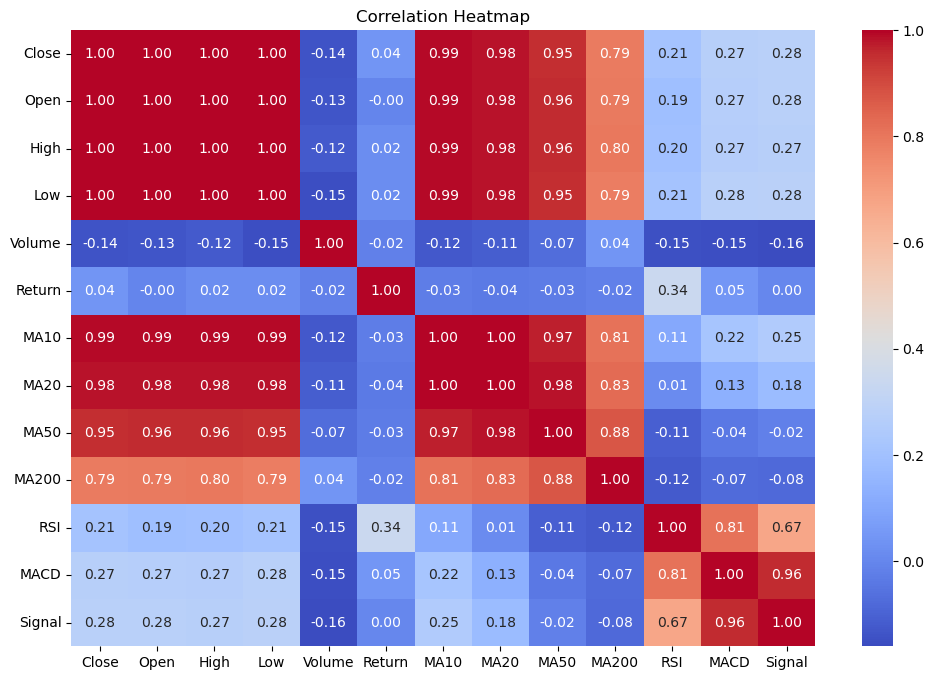

In [63]:
plt.figure(figsize=(12,8))
corr = df[['Close','Open','High','Low','Volume','Return','MA10','MA20','MA50','MA200','RSI','MACD','Signal']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


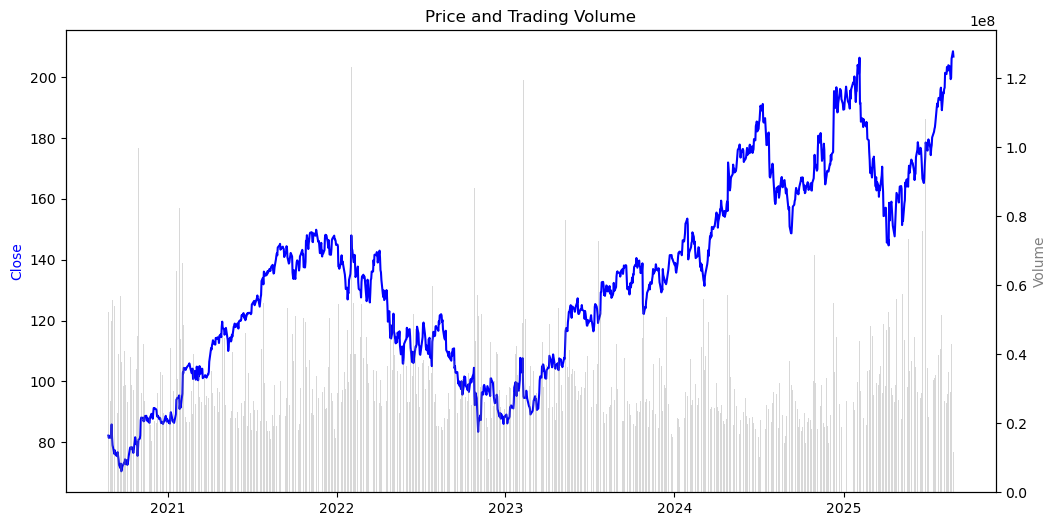

In [64]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(df['Date'], df['Close'], color='blue', label='Price')
ax1.set_ylabel("Close", color="blue")
ax2 = ax1.twinx()
ax2.bar(df['Date'], df['Volume'], alpha=0.3, color='gray', label='Volume')
ax2.set_ylabel("Volume", color="gray")

plt.title("Price and Trading Volume")
plt.show()

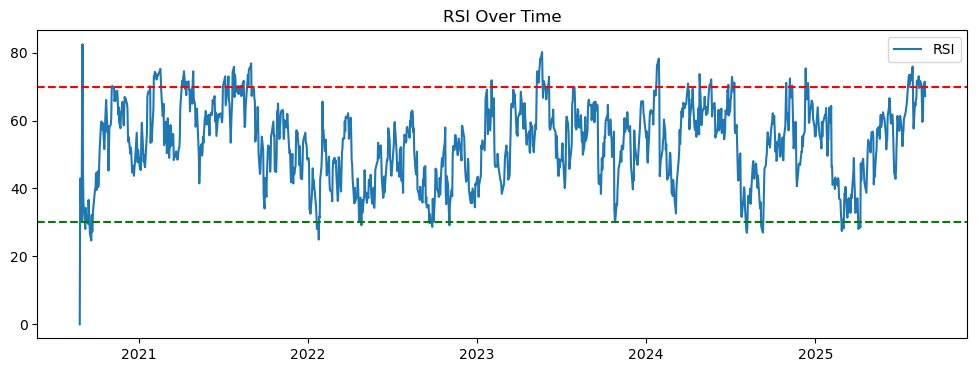

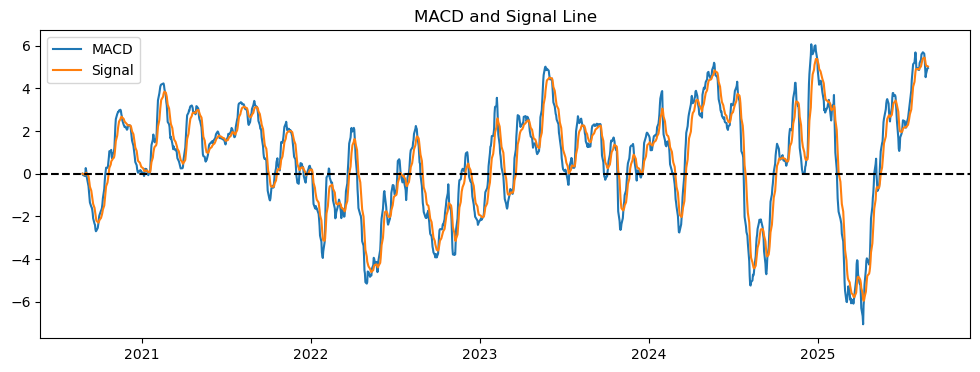

In [65]:
plt.figure(figsize=(12,4))
plt.plot(df['Date'], df['RSI'], label='RSI')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title("RSI Over Time")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df['Date'], df['MACD'], label='MACD')
plt.plot(df['Date'], df['Signal'], label='Signal')
plt.axhline(0, color='black', linestyle='--')
plt.title("MACD and Signal Line")
plt.legend()
plt.show()


#Testing

Creating the target variable (which is the next-day closing price)


In [66]:
df['y_next'] = df['Close'].shift(-1)

In [67]:
# Selecting features for H1, including lagged prices only:
features_A = ['Price_lag1', 'Price_lag5']
# Selecting features for H2 and H3, which are the lagged proces and the technical indicators:
features_B = features_A + [
    'MA10','MA20','MA50','MA200',
    'RSI','MACD','Signal','Volatility20','Volume'
]
trend_feats = ['trend_alphabet', 'trend_alphabet_lag1', 'trend_alphabet_lag7', 'trend_alphabet_lag28']
features_C  = features_A + [
    'MA10','MA20','MA50','MA200','RSI','MACD','Signal','Volatility20','Volume'
] + trend_feats
# The MovingAvg_10day is the short-term average, the MovingAvg_20day is the medium-term average.
# MovingAvg_50day is a medium/long-term average, and MovingAvg_200day is a long-term average.


In [68]:
# Dropping rows with missing/null values:

df = df.dropna(subset=features_B + ['y_next'])

X_A = df[features_A]   # for model A
X_B = df[features_B]   # for model B and gradient booting
X_C = df[features_C]

y = df['y_next']     # target (next day closing price)
dates = df['Date']

In [69]:
# Separating data chronologically:

#train_idx = dates < "2024-01-01"   # our training data (2021-2023)
#valid_idx = (dates >= "2024-01-01") & (dates < "2025-01-01") # just a validation data (2024)
#test_idx  = dates >= "2025-01-01"   # our testing data (2025)0

In [70]:
#walk forward
start_phase1 = "2020-09-01"
end_phase1   = "2024-01-01"

start_phase2 = "2024-01-01"
end_phase2   = "2025-01-01"

start_phase3 = "2025-01-01"
end_phase3   = None

Calculating evaluation metrics:

In [71]:
results = []
y_res = []

In [72]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "RMSE": root_mean_squared_error(y_true, y_pred),  # this will be our avg predictor error
        "MAE": mean_absolute_error(y_true, y_pred),    # error in monetary value
        "R2": r2_score(y_true, y_pred)    # % of the variance explained
    }

In [73]:
def walk_forward_predict(model, X, y, dates, start_date, end_date=None, min_train=60):
    y_true, y_pred = [], []

    mask_range = (dates >= pd.to_datetime(start_date)) & (
        dates < (pd.to_datetime(end_date) if end_date else dates.max() + pd.Timedelta(days=1))
    )
    eval_days = pd.to_datetime(dates[mask_range]).unique()

    for d in eval_days:
        train_mask = dates < d
        test_mask  = dates == d

        if train_mask.sum() < min_train or test_mask.sum() == 0:
            continue

        m = clone(model)
        m.fit(X.loc[train_mask], y.loc[train_mask])
        p = m.predict(X.loc[test_mask])

        y_true.append(y.loc[test_mask].iloc[0])
        y_pred.append(p[0])

    return np.array(y_true), np.array(y_pred)

**Multiple Linear Regression - Features A**

In [74]:
# Model A (H1):
pipe_lr_A = Pipeline([
    ("scaler", StandardScaler()),      # normalizing data so we can compare them properly
    ("lr", LinearRegression())
])
#pipe_lr_A.fit(X_A[train_idx], y[train_idx])

In [75]:
#Training
y_valid_true, y_valid_pred = walk_forward_predict(
    model=pipe_lr_A,
    X=X_A,
    y=y,
    dates=dates,
    start_date=start_phase1,
    end_date=end_phase1,
    min_train=60
)
y_res.append({
    "name": "LR_A - WF Phase1",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("LR_A - WF Phase1", y_valid_true, y_valid_pred))

# Validation
y_test_true, y_test_pred = walk_forward_predict(
    model=pipe_lr_A,
    X=X_A,
    y=y,
    dates=dates,
    start_date=start_phase2,
    end_date=end_phase2,
    min_train=60
)
y_res.append({
    "name": "LR_A - WF Phase2",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("LR_A - WF Phase2", y_test_true, y_test_pred))

# TEST
y_test_true, y_test_pred = walk_forward_predict(
    model=pipe_lr_A,
    X=X_A,
    y=y,
    dates=dates,
    start_date=start_phase3,
    end_date=end_phase3,
    min_train=60
)
y_res.append({
    "name": "LR_A - WF Phase3",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("LR_A - WF Phase3", y_test_true, y_test_pred))

**Multiple Linear Regression - Features B**

In [76]:
# Model B (H2):
pipe_lr_B = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])
#pipe_lr_B.fit(X_B[train_idx], y[train_idx])

In [77]:
#Training
y_valid_true, y_valid_pred = walk_forward_predict(
    model=pipe_lr_B,
    X=X_B,
    y=y,
    dates=dates,
    start_date=start_phase1,
    end_date=end_phase1,
    min_train=60
)
y_res.append({
    "name": "LR_B - WF Phase1",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("LR_B - WF Phase1", y_valid_true, y_valid_pred))

# Validation
y_test_true, y_test_pred = walk_forward_predict(
    model=pipe_lr_B,
    X=X_B,
    y=y,
    dates=dates,
    start_date=start_phase2,
    end_date=end_phase2,
    min_train=60
)
y_res.append({
    "name": "LR_B - WF Phase2",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("LR_B - WF Phase2", y_test_true, y_test_pred))

# TEST
y_test_true, y_test_pred = walk_forward_predict(
    model=pipe_lr_B,
    X=X_B,
    y=y,
    dates=dates,
    start_date=start_phase3,
    end_date=end_phase3,
    min_train=60
)
y_res.append({
    "name": "LR_B - WF Phase3",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("LR_B - WF Phase3", y_test_true, y_test_pred))

**Multiple Linear Regression - Features C**

In [78]:
pipe_lr_C = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])
#pipe_lr_C.fit(X_C[train_idx], y[train_idx])

In [79]:
#Training
y_valid_true, y_valid_pred = walk_forward_predict(
    model=pipe_lr_C,
    X=X_C,
    y=y,
    dates=dates,
    start_date=start_phase1,
    end_date=end_phase1,
    min_train=60
)
y_res.append({
    "name": "LR_C - WF Phase1",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("LR_C - WF Phase1", y_valid_true, y_valid_pred))

# Validation
y_test_true, y_test_pred = walk_forward_predict(
    model=pipe_lr_C,
    X=X_C,
    y=y,
    dates=dates,
    start_date=start_phase2,
    end_date=end_phase2,
    min_train=60
)
y_res.append({
    "name": "LR_C - WF Phase2",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("LR_C - WF Phase2", y_test_true, y_test_pred))

# TEST
y_test_true, y_test_pred = walk_forward_predict(
    model=pipe_lr_C,
    X=X_C,
    y=y,
    dates=dates,
    start_date=start_phase3,
    end_date=end_phase3,
    min_train=60
)
y_res.append({
    "name": "LR_C - WF Phase3",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("LR_C - WF Phase3", y_test_true, y_test_pred))

**Machine Learning**

**Gradient Boosting**

In [80]:
mask_tune = (pd.to_datetime(dates) < pd.Timestamp("2024-01-01"))

gb = GradientBoostingRegressor(random_state=42)

param_grid = {
    "n_estimators":   [300, 600],
    "learning_rate":  [0.05, 0.1],
    "max_depth":      [2, 3],
    "min_samples_leaf":[1, 5],
    "subsample":      [1.0, 0.9],   # 0.9 suele ayudar a generalizar
}

tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    refit=False,
    n_jobs=-1
)

In [81]:
grid.fit(X_B.loc[mask_tune], y.loc[mask_tune])

best_params = grid.best_params_
best_gb = GradientBoostingRegressor(**best_params, random_state=42)
print("Best GB params:", best_params)

Best GB params: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 5, 'n_estimators': 300, 'subsample': 0.9}


In [82]:
# A) Fase 1 (2020-09-01 .. 2023-12-31)
y_p1_true, y_p1_pred = walk_forward_predict(
    model=best_gb, X=X_B, y=y, dates=pd.to_datetime(dates),
    start_date=start_phase1, end_date=end_phase1, min_train=252
)
y_res.append({
    "name": "GB_B - WF Phase1",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("GB_B - WF Phase1", y_p1_true, y_p1_pred))

# B) Fase 2 (2024)
y_p2_true, y_p2_pred = walk_forward_predict(
    model=best_gb, X=X_B, y=y, dates=pd.to_datetime(dates),
    start_date=start_phase2, end_date=end_phase2, min_train=252
)
y_res.append({
    "name": "GB_B - WF Phase2",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("GB_B - WF Phase2", y_p2_true, y_p2_pred))

# C) Fase 3 (2025+)
y_p3_true, y_p3_pred = walk_forward_predict(
    model=best_gb, X=X_B, y=y, dates=pd.to_datetime(dates),
    start_date=start_phase3, end_date=end_phase3, min_train=252
)
y_res.append({
    "name": "GB_B - WF Phase3",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("GB_B - WF Phase3", y_p3_true, y_p3_pred))

In [83]:
grid.fit(X_C.loc[mask_tune], y.loc[mask_tune])

best_params = grid.best_params_
best_gb = GradientBoostingRegressor(**best_params, random_state=42)
print("Best GB params:", best_params)

Best GB params: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 5, 'n_estimators': 300, 'subsample': 0.9}


In [84]:
# A) Fase 1 (2020-09-01 .. 2023-12-31)
y_p1_true, y_p1_pred = walk_forward_predict(
    model=best_gb, X=X_C, y=y, dates=pd.to_datetime(dates),
    start_date=start_phase1, end_date=end_phase1, min_train=252
)
y_res.append({
    "name": "GB_C - WF Phase1",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("GB_C - WF Phase1", y_p1_true, y_p1_pred))

# B) Fase 2 (2024)
y_p2_true, y_p2_pred = walk_forward_predict(
    model=best_gb, X=X_C, y=y, dates=pd.to_datetime(dates),
    start_date=start_phase2, end_date=end_phase2, min_train=252
)
y_res.append({
    "name": "GB_C - WF Phase2",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("GB_C - WF Phase2", y_p2_true, y_p2_pred))

# C) Fase 3 (2025+)
y_p3_true, y_p3_pred = walk_forward_predict(
    model=best_gb, X=X_C, y=y, dates=pd.to_datetime(dates),
    start_date=start_phase3, end_date=end_phase3, min_train=252
)
y_res.append({
    "name": "GB_C - WF Phase3",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("3GB_C - WF Phase", y_p3_true, y_p3_pred))

**Random Forest**

In [85]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
param_grid = {
    "n_estimators": [400, 800],
    "max_depth": [10, None],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", 0.7]
}
tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(rf, param_grid, cv=tscv,
                    scoring="neg_root_mean_squared_error",
                    refit=False, n_jobs=-1)


In [86]:
grid.fit(X_B.loc[mask_tune], y.loc[mask_tune])

best_rf = RandomForestRegressor(**grid.best_params_, random_state=42, n_jobs=-1)

# 2) Walk-forward por fases (usa tus variables ya definidas)
# start_phase1="2020-09-01"; end_phase1="2024-01-01"
# start_phase2="2024-01-01"; end_phase2="2025-01-01"
# start_phase3="2025-01-01"; end_phase3=None

y_p1_true, y_p1_pred = walk_forward_predict(best_rf, X_B, y, dates, start_phase1, end_phase1, min_train=252)
y_res.append({
    "name": "RF_B - WF Phase1",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("RF_B - WF Phase1", y_p1_true, y_p1_pred))

y_p2_true, y_p2_pred = walk_forward_predict(best_rf, X_B, y, dates, start_phase2, end_phase2, min_train=252)
y_res.append({
    "name": "RF_B - WF Phase2",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("RF_B - WF Phase2", y_p2_true, y_p2_pred))

y_p3_true, y_p3_pred = walk_forward_predict(best_rf, X_B, y, dates, start_phase3, end_phase3, min_train=252)
y_res.append({
    "name": "RF_B - WF Phase3",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("RF_B - WF Phase3", y_p3_true, y_p3_pred))

In [87]:
grid.fit(X_C.loc[mask_tune], y.loc[mask_tune])

best_rf = RandomForestRegressor(**grid.best_params_, random_state=42, n_jobs=-1)

# 2) Walk-forward por fases (usa tus variables ya definidas)
# start_phase1="2020-09-01"; end_phase1="2024-01-01"
# start_phase2="2024-01-01"; end_phase2="2025-01-01"
# start_phase3="2025-01-01"; end_phase3=None

y_p1_true, y_p1_pred = walk_forward_predict(best_rf, X_C, y, dates, start_phase1, end_phase1, min_train=252)
y_res.append({
    "name": "RF_C - WF Phase1",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("RF_C - WF Phase1", y_p1_true, y_p1_pred))

y_p2_true, y_p2_pred = walk_forward_predict(best_rf, X_C, y, dates, start_phase2, end_phase2, min_train=252)
y_res.append({
    "name": "RF_C - WF Phase2",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("RF_C - WF Phase2", y_p2_true, y_p2_pred))

y_p3_true, y_p3_pred = walk_forward_predict(best_rf, X_C, y, dates, start_phase3, end_phase3, min_train=252)
y_res.append({
    "name": "RF_C - WF Phase3",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
})
results.append(evaluate_model("RF_C - WF Phase3", y_p3_true, y_p3_pred))

**ARIMA**

In [88]:
#rf = RandomForestRegressor(random_state=42, n_jobs=-1)
#param_grid = {
#    "n_estimators": [300, 600],
#    "max_depth": [None, 6, 12],
#    "min_samples_leaf": [1, 2, 5],
#    "min_samples_split": [2, 5, 10],
#    "max_features": ["sqrt", "log2", 0.5],   # fraction is ok in recent sklearn
#    "bootstrap": [True]
#}
#grid = GridSearchCV(
#    rf,
#    param_grid,
#    cv=[(train_idx, valid_idx)],                       # same split you used elsewhere
#    scoring="neg_root_mean_squared_error",
#    n_jobs=-1,
#    refit=False
#)
#grid.fit(X_B, y)
#best_params = grid.best_params_
#print("RF best params:", best_params)


In [89]:
#best_rf = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
#best_rf.fit(X_B[train_idx | valid_idx], y[train_idx | valid_idx])

In [90]:
#results.append(evaluate_model("RF - Valid",  y[valid_idx], best_rf.predict(X_B[valid_idx])))

#results.append(evaluate_model("RF - Test",  y[test_idx],  best_rf.predict(X_B[test_idx])))

In [91]:
#rf = RandomForestRegressor(random_state=42, n_jobs=-1)
#param_grid = {
#    "n_estimators":[300,600], "max_depth":[None,6,12],
#    "min_samples_leaf":[1,2,5], "min_samples_split":[2,5,10],
#    "max_features":["sqrt","log2",0.5], "bootstrap":[True]
#}
#grid = GridSearchCV(rf, param_grid, cv=[(train_idx, valid_idx)],
#                    scoring="neg_root_mean_squared_error", n_jobs=-1, refit=False)
#grid.fit(X_C, y)
#best_rf_C = RandomForestRegressor(**grid.best_params_, random_state=42, n_jobs=-1)
#best_rf_C.fit(X_C[train_idx | valid_idx], y[train_idx | valid_idx])

#results.append(evaluate_model("RF (with trend) - Valid",
#                             y[valid_idx], best_rf_C.predict(X_C[valid_idx])))
#results.append(evaluate_model("RF (with trend) - Test",
#                             y[test_idx],  best_rf_C.predict(X_C[test_idx])))


In [92]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [93]:
# Serie temporal principal
series = df.set_index("Date")["Close"].sort_index()

# Exógenas para ARIMAX
exog_B = df.set_index("Date")[features_B].sort_index()
exog_C = df.set_index("Date")[features_C].sort_index()

# Alinear índices (por si hay valores faltantes)
common_idx = series.index.intersection(exog_B.index).intersection(exog_C.index)
series  = series.loc[common_idx]
exog_B  = exog_B.loc[common_idx]
exog_C  = exog_C.loc[common_idx]

In [94]:
idx = series.index.intersection(exog_B.index).intersection(exog_C.index)
series = series.loc[idx]; exog_B = exog_B.loc[idx]; exog_C = exog_C.loc[idx]

# Fechas por fase
valid_mask_p2 = (series.index >= start_phase2) & (series.index < end_phase2)
test_mask_p3  = (series.index >= start_phase3)

valid_dates = series.loc[valid_mask_p2].index.tolist()
test_dates  = series.loc[test_mask_p3].index.tolist()

In [95]:
def arimax_walk_forward(series, exog, anchor_dates, order=(1,1,1)):
    preds = []
    for t in anchor_dates:
        # historia <= t
        hist = series.loc[:t]
        Xhist = exog.loc[:t]
        # próxima fecha disponible
        try:
            next_pos = series.index.get_indexer([pd.Timestamp(t)], method='pad')[0] + 1
            if next_pos >= len(series.index): break
            next_dt = series.index[next_pos]
        except: continue
        Xfore = exog.loc[[next_dt]]
        res = SARIMAX(hist, exog=Xhist, order=order,
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        preds.append(res.forecast(steps=1, exog=Xfore).iloc[0])
    return pd.Series(preds, index=pd.to_datetime(anchor_dates[:len(preds)]))

def eval_arimax_3phases(series, exog, y, label, order=(1,1,1)):
    # Phase 1
    p1_dates = series.loc[(series.index >= start_phase1) & (series.index < end_phase1)].index.tolist()
    p1_pred  = arimax_walk_forward(series, exog, p1_dates, order=order)
    p1_true  = y.loc[y.index.isin(p1_pred.index)]
    y_res.append({
    "name": "f{label} - WF Phase1",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
    })
    results.append(evaluate_model(f"{label} - WF Phase1", p1_true, p1_pred))

    # Phase 2
    p2_pred  = arimax_walk_forward(series, exog, valid_dates, order=order)
    p2_true  = y.loc[y.index.isin(p2_pred.index)]
    y_res.append({
    "name": "f{label} - WF Phase2",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
    })
    results.append(evaluate_model(f"{label} - WF Phase2", p2_true, p2_pred))

    # Phase 3
    p3_pred  = arimax_walk_forward(series, exog, test_dates, order=order)
    p3_true  = y.loc[y.index.isin(p3_pred.index)]
    y_res.append({
    "name": "f{label} - WF Phase3",
    "y_true": y_valid_true,
    "y_pred": y_valid_pred
    })
    results.append(evaluate_model(f"{label} - WF Phase3", p3_true, p3_pred))



In [96]:
def arimax_walk_forward_robust(series, exog, anchor_dates, order=(1,1,1), min_nobs=None):
    """
    Walk-forward 1-step ahead para ARIMAX con salvaguardas.
    - series: pd.Series indexada por fecha
    - exog:   pd.DataFrame indexado por la MISMA fecha, mismas columnas en todo momento
    - anchor_dates: lista de fechas t para 'ajustar con <= t' y pronosticar t+1
    - order: (p,d,q)
    - min_nobs: mínimo de observaciones para entrenar; si None usa max(30, p+q+2)
    """
    p, d, q = order
    if min_nobs is None:
        min_nobs = max(30, p + q + 2)  # evita "maxlag should be < nobs"

    preds = []
    out_idx = []

    idx_all = series.index
    cols = list(exog.columns)

    # Asegura 2D y columnas consistentes
    exog = exog.copy()
    exog = exog[cols]

    for t in anchor_dates:
        # Posición de t y de t+1 en el índice de la serie
        pos_t = idx_all.searchsorted(pd.Timestamp(t))
        if pos_t >= len(idx_all):
            break
        pos_next = pos_t + 1
        if pos_next >= len(idx_all):
            break

        # Historia hasta t (inclusive)
        y_hist = series.iloc[:pos_t+1]
        X_hist = exog.iloc[:pos_t+1]

        # Exógena para t+1
        X_fore = exog.iloc[[pos_next]]  # DataFrame de 1xk

        # Salvaguardas
        if len(y_hist) < min_nobs:
            continue
        if X_hist.isna().any().any() or X_fore.isna().any().any():
            continue  # evita dimensiones raras por NaNs
        if list(X_hist.columns) != cols or list(X_fore.columns) != cols:
            continue  # columnas deben coincidir exactamente

        # Ajustar y pronosticar
        try:
            res = SARIMAX(
                y_hist, exog=X_hist, order=order,
                enforce_stationarity=False, enforce_invertibility=False
            ).fit(disp=False)
            y_hat = res.forecast(steps=1, exog=X_fore).iloc[0]
        except Exception:
            continue  # si alguna iteración falla, sáltala

        preds.append(y_hat)
        out_idx.append(idx_all[pos_next])

    return pd.Series(preds, index=pd.to_datetime(out_idx), name="y_hat")


In [97]:
# Fases
start_phase1 = "2020-09-01"; end_phase1 = "2024-01-01"
start_phase2 = "2024-01-01"; end_phase2 = "2025-01-01"
start_phase3 = "2025-01-01"; end_phase3 = None

# Listas de fechas ancla por fase (las t a evaluar)
p1_dates = series.loc[(series.index >= start_phase1) & (series.index < end_phase1)].index.tolist()
p2_dates = series.loc[(series.index >= start_phase2) & (series.index < end_phase2)].index.tolist()
p3_dates = series.loc[(series.index >= start_phase3)].index.tolist()

order = (1,1,1)  # ajusta si hiciste AIC-scan previo

# B (sin trends)
pred_B_p1 = arimax_walk_forward_robust(series, exog_B, p1_dates, order=order)
pred_B_p2 = arimax_walk_forward_robust(series, exog_B, p2_dates, order=order)
pred_B_p3 = arimax_walk_forward_robust(series, exog_B, p3_dates, order=order)

# C (con trends)
pred_C_p1 = arimax_walk_forward_robust(series, exog_C, p1_dates, order=order)
pred_C_p2 = arimax_walk_forward_robust(series, exog_C, p2_dates, order=order)
pred_C_p3 = arimax_walk_forward_robust(series, exog_C, p3_dates, order=order)


c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\ProgramData\anaconda3\Lib\sit

In [98]:
def eval_series(name, y_true_series, y_pred_series):
    y_true = y_true_series.reindex(y_pred_series.index)  # alinear por fechas
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred_series).reshape(-1)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    rmse = np.sqrt(((y_true - y_pred)**2).mean())
    mae  = np.abs(y_true - y_pred).mean()
    ss_res = ((y_true - y_pred)**2).sum()
    ss_tot = ((y_true - y_true.mean())**2).sum()
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

# y debe estar indexado por Date y alineado con series
y_series = y.copy()
y_series.index = series.index  # si ya coinciden, omite

In [99]:
results.append(eval_series("ARIMAX (B) - WF Phase1", y_series, pred_B_p1))
results.append(eval_series("ARIMAX (B) - WF Phase2", y_series, pred_B_p2))
results.append(eval_series("ARIMAX (B) - WF Phase3", y_series, pred_B_p3))

In [100]:
results.append(eval_series("ARIMAX (C) - WF Phase1", y_series, pred_C_p1))
results.append(eval_series("ARIMAX (C) - WF Phase2", y_series, pred_C_p2))
results.append(eval_series("ARIMAX (C) - WF Phase3", y_series, pred_C_p3))

# Testing Visualization

In [101]:
# Final results table:

results_df = pd.DataFrame(results)
print("\nModel Evaluation Results:")
results_df


Model Evaluation Results:


,Model,RMSE,MAE,R2
0,LR_A - WF Phase1,3.479186,2.688316,0.961362
1,LR_A - WF Phase2,4.213568,3.181089,0.924685
2,LR_A - WF Phase3,4.707754,3.684060,0.914693
3,LR_B - WF Phase1,2.730959,2.065046,0.976194
4,LR_B - WF Phase2,3.177457,2.339538,0.957171
5,LR_B - WF Phase3,4.032161,3.112884,0.937420
6,LR_C - WF Phase1,2.765257,2.097284,0.975592
7,LR_C - WF Phase2,3.171962,2.338469,0.957319
8,LR_C - WF Phase3,3.999956,3.041047,0.938416
9,GB_B - WF Phase1,2.922390,2.208737,0.966441


In [102]:
# ln_regA_pred = pipe_lr_A.predict(X_A[test_idx])
# ln_regB_pred = pipe_lr_B.predict(X_B[test_idx])
# arima_test_pred
# gb_pred = best_gb.predict(X_B[test_idx])
# rf_pred = rf.predict(X_B.loc[test_idx])


In [103]:


# # 1) Today’s close (t) for test rows
# close_t = df.loc[test_idx, 'Price'].astype(float)

# # 2) Next-day predictions (t+1) for the same test rows
# ln_regB_pred = np.asarray(pipe_lr_B.predict(X_B.loc[test_idx])).ravel()
# pred_s = pd.Series(ln_regB_pred, index=close_t.index, name='ln_regB_pred')
# dates = pd.to_datetime(df.loc[test_idx, 'Date'])

# # 4) exp_ret as requested (close_t / ln_regB_pred)
# exp_ret = (close_t / pred_s)

# # 5) Recommendation logic (use expected growth = pred/close - 1)
# thr = 0.005      # 0.5% no-trade band
# tx_cost = 0.0005 # 0.05% one-way cost buffer; set to 0 to ignore costs

# signal_ret = (pred_s / close_t) - 1  # this is the intuitive expected return
# recomendation = np.where(signal_ret > (thr + tx_cost), 'BUY',
#                   np.where(signal_ret < -(thr + tx_cost), 'SELL', 'HOLD'))

# # 6) Build reco_df indexed by Date
# reco_df = pd.DataFrame({
#     'Date': dates.values,
#     'close_t': close_t.values,
#     'ln_regA_pred': pred_s.values,
#     'exp_ret': exp_ret.values,              # NOTE: this is close_t / pred_t1 as requested
#     'recomendation': recomendation
# }).set_index('Date').sort_index()

# print(reco_df['recomendation'].value_counts())
# reco_df


In [104]:

# 1) today's close (t) and dates for test rows
close_t = df.loc[test_idx, 'Close'].astype(float)
dates   = pd.to_datetime(df.loc[test_idx, 'Date'])

# 2) predictions for the same test rows → align by index
arima_pred_s = pd.Series(np.asarray(arima_test_pred, dtype=float),
                         index=close_t.index,
                         name='arima_test_pred').shift(-1)

# 3) exp_ret as requested (close_t / arima_pred)
exp_ret = (close_t / arima_pred_s)

# 4) recommendations via expected return = pred/close - 1
thr = 0.005      # 0.5% no-trade band
tx_cost = 0.0005 # 0.05% one-way transaction cost buffer

signal_ret = (arima_pred_s / close_t) - 1
recommendation = np.where(signal_ret > (thr + tx_cost), 'BUY',
                  np.where(signal_ret < -(thr + tx_cost), 'SELL', 'HOLD'))

# 5) build reco_df indexed by Date
reco_df = pd.DataFrame({
    'Date': dates.values,
    'close_t': close_t.values,
    'arima_test_pred': arima_pred_s.values,
    'exp_ret': exp_ret.values,              # note: this is close_t / pred, per your spec
    'Recommendation': recommendation
}).set_index('Date').sort_index()

# (optional) quick checks
# assert len(arima_test_pred) == int(np.asarray(test_idx).sum())
print(reco_df['Recommendation'].value_counts())
reco_df


NameError: name 'test_idx' is not defined

In [ ]:
# Simulate trading based on reco_df recommendations
pos = 0
avg_cost = 0.0
cum_mult = 1.0   # compounding multiplier of realized trades

pos_list = []
avg_cost_list = []
trade_pnl_pct_list = []
cum_pnl_pct_list = []
unreal_pnl_pct_list = []

for _, row in reco_df.iterrows():
    price = float(row["close_t"])
    rec = row["Recommendation"]

    trade_pnl_pct = 0.0

    if rec == "BUY":
        # buy exactly 1 unit
        pos_new = pos + 1
        avg_cost = (avg_cost * pos + price) / pos_new if pos > 0 else price
        pos = pos_new

    elif rec == "SELL":
        if pos > 0:
            # realized profit %
            trade_pnl_pct = (price - avg_cost) / avg_cost * 100.0
            cum_mult *= (1.0 + trade_pnl_pct / 100.0)
            pos = 0
            avg_cost = 0.0
        # else: already flat, no transaction

    # unrealized profit %
    unreal_pnl_pct = ((price - avg_cost) / avg_cost * 100.0) if pos > 0 else 0.0

    # store step-by-step values
    pos_list.append(pos)
    avg_cost_list.append(avg_cost)
    trade_pnl_pct_list.append(trade_pnl_pct)
    unreal_pnl_pct_list.append(unreal_pnl_pct)
    cum_pnl_pct_list.append((cum_mult - 1.0) * 100.0)

# add results to dataframe
reco_df["Position"] = pos_list
reco_df["AvgCost"] = avg_cost_list
reco_df["Trade Profit&Loss (%)"] = trade_pnl_pct_list
reco_df["Unrealized Profit&Loss (%)"] = unreal_pnl_pct_list
reco_df["Cumulative Profit&Loss (%)"] = cum_pnl_pct_list

# trade log = only rows where we sold
cols_to_show = ["close_t", "Trade Profit&Loss (%)", "Cumulative Profit&Loss (%)"]
if "Date" in reco_df.columns:
    cols_to_show = ["Date"] + cols_to_show

trade_log = reco_df[reco_df["Trade Profit&Loss (%)"] != 0][cols_to_show]

# print(reco_df.tail())
# print("\nTrade log:")
# print(trade_log)

reco_df


In [ ]:

# X-axis (Date if present, else row index)
x = reco_df["Date"] if "Date" in reco_df.columns else np.arange(len(reco_df))

# Helper masks
is_buy  = reco_df["Recommendation"].eq("BUY")
is_sell = reco_df["Recommendation"].eq("SELL") & (reco_df["Trade Profit&Loss (%)"] != 0)

# --- 1) Price + Position (two axes) ---
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(x, reco_df["close_t"], label="Price")
ax1.set_xlabel("Date" if "Date" in reco_df.columns else "Index")
ax1.set_ylabel("Price")

# Trade markers on price
ax1.scatter(x[is_buy],  reco_df.loc[is_buy, "close_t"], marker="^", s=60, label="BUY")
ax1.scatter(x[is_sell], reco_df.loc[is_sell, "close_t"], marker="v", s=60, label="SELL")

# Position (right axis)
ax2 = ax1.twinx()
ax2.plot(x, reco_df["Position"], linestyle="--", label="Position")
ax2.set_ylabel("Units held")

# Combined legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")
plt.title("Price & Position")
plt.tight_layout()
plt.show()

# --- 2) Cumulative Realized P&L (%) ---
plt.figure(figsize=(10, 3.5))
plt.plot(x, reco_df["Cumulative Profit&Loss (%)"])
plt.title("Cumulative Realized P&L (%)")
plt.xlabel("Date" if "Date" in reco_df.columns else "Index")
plt.ylabel("%")
plt.tight_layout()
plt.show()

# --- 3) Unrealized P&L (%) (only meaningful while holding) ---
plt.figure(figsize=(10, 3.5))
plt.plot(x, reco_df["Unrealized Profit&Loss (%)"])
plt.title("Unrealized P&L (%)")
plt.xlabel("Date" if "Date" in reco_df.columns else "Index")
plt.ylabel("%")
plt.tight_layout()
plt.show()

# --- 4) Optional: bar chart of SELL trade returns only ---
trade_rows = reco_df["Trade Profit&Loss (%)"] != 0
if trade_rows.any():
    x_trades = reco_df.loc[trade_rows, "Date"] if "Date" in reco_df.columns else np.arange(len(reco_df))[trade_rows]
    plt.figure(figsize=(10, 3))
    plt.bar(x_trades, reco_df.loc[trade_rows, "Trade Profit&Loss (%)"])
    plt.title("Per-Trade Realized P&L (%) — SELL events")
    plt.xlabel("Date" if "Date" in reco_df.columns else "Index")
    plt.ylabel("%")
    plt.tight_layout()
    plt.show()


In [ ]:
# X-axis (Date if present, else row index)
x = reco_df["Date"] if "Date" in reco_df.columns else np.arange(len(reco_df))

equity = 1.0 + reco_df["Cumulative Profit&Loss (%)"] / 100.0

plt.figure(figsize=(10, 3.5))
plt.plot(x, equity)
plt.title("Equity Curve (compounded)")
plt.xlabel("Date" if "Date" in reco_df.columns else "Index")
plt.ylabel("Value (start = 1.0)")
plt.tight_layout()
plt.show()


In [ ]:
# Helper masks
is_buy  = reco_df["Recommendation"].eq("BUY")
is_sell = reco_df["Recommendation"].eq("SELL") & (reco_df["Trade Profit&Loss (%)"] != 0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, reco_df["close_t"], label="Price")

# Markers
ax.scatter(x[is_buy],  reco_df.loc[is_buy,  "close_t"], marker="^", s=60, label="BUY")
ax.scatter(x[is_sell], reco_df.loc[is_sell, "close_t"], marker="v", s=60, label="SELL")

# Annotate SELLs with realized P&L %
for xi, p, r in zip(
    x[is_sell],
    reco_df.loc[is_sell, "close_t"],
    reco_df.loc[is_sell, "Trade Profit&Loss (%)"]
):
    ax.annotate(f"{r:.1f}%", xy=(xi, p), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=8)

ax.set_title("Price with BUY/SELL markers and SELL returns")
ax.set_xlabel("Date" if "Date" in reco_df.columns else "Index")
ax.set_ylabel("Price")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


In [ ]:
# Evaluate if the recommendation strategy (H4) is better than buy-and-hold after costs
cost_rate = 0.0005  # adjust if you want a different after-cost assumption

# 0) Ensure datetime index alignment
prices = df.copy()
prices['Date'] = pd.to_datetime(prices['Date'])
prices = prices.set_index('Date').sort_index()
reco_df = reco_df.copy()
if 'Date' in reco_df.columns:
    reco_df['Date'] = pd.to_datetime(reco_df['Date'])
    reco_df = reco_df.set_index('Date')
reco_df = reco_df.sort_index()

# 1) Map recommendations -> positions p_t ∈ {0,1}
sig_col = 'Recommendation'
signals = reco_df[sig_col].astype(str).str.upper().map({'BUY': 1, 'SELL': 0, 'HOLD': np.nan})

# Carry forward holds; start flat if first is NaN
positions = signals.ffill().fillna(0).astype(int)

# 2) Realized next-day returns r_{t+1} = Close_{t+1}/Close_t - 1
close_t  = prices['Close'].reindex(reco_df.index)
close_t1 = prices['Close'].shift(-1).reindex(reco_df.index)

# Drop last date if no next-day price available
valid_mask = close_t.notna() & close_t1.notna()
positions = positions[valid_mask]
close_t   = close_t[valid_mask]
close_t1  = close_t1[valid_mask]

ret_bh = (close_t1 / close_t) - 1  # buy-and-hold daily return over t->t+1

# 3) Strategy returns with transaction costs on position changes
# Cost applied on the day we change the position (t), before earning r_{t+1}
turnover = positions.diff().abs().fillna(positions.iloc[0])  # 1 when switching 0↔1
ret_strat = (positions * ret_bh) - (cost_rate * turnover)

# 4) Performance metrics
def _cumret(r): return (1 + r).prod() - 1
def _ann_sharpe(r, periods_per_year=252):
    if r.std(ddof=0) == 0:
        return np.nan
    return (r.mean() / r.std(ddof=0)) * np.sqrt(periods_per_year)
def _max_drawdown(r):
    equity = (1 + r).cumprod()
    peak = equity.cummax()
    dd = (equity / peak) - 1
    return dd.min()

metrics = pd.DataFrame({
    'Strategy': ['Recommendation', 'Buy&Hold'],
    'CumReturn': [_cumret(ret_strat), _cumret(ret_bh)],
    'AnnSharpe' : [_ann_sharpe(ret_strat), _ann_sharpe(ret_bh)],
    'MaxDrawdown': [_max_drawdown(ret_strat), _max_drawdown(ret_bh)],
    'AvgDailyRet': [ret_strat.mean(), ret_bh.mean()],
    'DailyVol'   : [ret_strat.std(ddof=0), ret_bh.std(ddof=0)],
    'TurnoverDays': [int((turnover > 0).sum()), 0],
    'HitRate(>0)': [float((ret_strat > 0).mean()), float((ret_bh > 0).mean())]
})

# 5) Decide H4
h4_supported = bool(metrics.loc[metrics['Strategy']=='Recommendation', 'CumReturn'].values[0] >
                    metrics.loc[metrics['Strategy']=='Buy&Hold', 'CumReturn'].values[0])

print(f"Test window: {close_t.index.min().date()} → {close_t.index.max().date()}")
print(f"H4 supported (higher cumulative net return after costs): {h4_supported}\n")
display(metrics.round(4))

# equity curves for report
equity_strat = (1 + ret_strat).cumprod()
equity_bh    = (1 + ret_bh).cumprod()
equity = pd.DataFrame({'Strategy': equity_strat, 'Buy&Hold': equity_bh})
equity.plot(title='Equity Curve: Recommendation Strategy vs Buy&Hold', figsize=(9,4));
